<a href="https://colab.research.google.com/github/jptrainor4-glitch/Data-Analytics/blob/main/Bars_data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
'''
Which parts of the Melbourne CBD have strong evening foot traffic but relatively few bar and pub seats,
making them good spots for a new venue?
'''

In [ ]:
import pandas as pd
import os
from google.colab import files, drive
import matplotlib.pyplot as plt
import shutil # Import shutil for file operations

drive.mount('/content/drive')                                   #Mount Google Drive

drive_folder = '/content/drive/MyDrive/colab_data/'             # Define the path where you want to save the file in Google Drive

os.makedirs(drive_folder, exist_ok=True)                        # Create the folder if it doesn't exist

expected_filename = 'bars-and-pubs-with-patron-capacity.csv'
drive_filepath = os.path.join(drive_folder, expected_filename)


if os.path.exists(drive_filepath):                              # Check if the file already exists in Google Drive
    print(f"Loading '{expected_filename}' from Google Drive...")
    df = pd.read_csv(drive_filepath)
else:
    print(f"'{expected_filename}' not found in Google Drive. Please upload it.")
    uploaded = files.upload()

    if uploaded:
        filename = list(uploaded.keys())[0]
        df = pd.read_csv(filename)

        shutil.copyfile(filename, drive_filepath)              # Save the uploaded file to Google Drive for future use
        os.remove(filename)                                    # Remove the temporary uploaded file
        print(f"'{filename}' uploaded and saved to Google Drive at '{drive_filepath}'.")
    else:
        print("No file was uploaded. Creating an empty DataFrame.")
        df = pd.DataFrame()                                    # Create an empty DataFrame if no file is uploaded

In [20]:
df.columns

Index(['Census year', 'Block ID', 'Property ID', 'Base property ID',
       'Building address', 'CLUE small area', 'Trading name',
       'Business address', 'Number of patrons', 'Longitude', 'Latitude',
       'location'],
      dtype='object')

In [ ]:
#How many rows and columns are there?

'''12 columns, 5304 rows.'''

#What does one row represent? This is the most important question on the list.
#Is it one venue, or something else? Look at the columns and think about why the same bar might show up more than once.
'''One row represents an entry for a specfic venue on a specific census year.
The same bar can show up more than once in the data set as it is recorded year for year.'''


#Which columns are numbers and which are text? Did pandas read them as the right types?

df['Block ID'] = df['Block ID'].astype(str)                     #Convert label information into strings
df['Base property ID'] = df['Base property ID'].astype(str)
df['Property ID'] = df['Property ID'].astype(str)

df.info()

#Where are the missing values, and how many are there?
''' There are 5284 entries for the geographic coordinants, meaning 20 entries are missing this information.'''

#Which years does the data cover, and how many rows are in each year?
print('\n', 'min', df['Census year'].min(), 'max', df['Census year'].max(), '\n')

'''2002 - 2024'''

result = df.groupby('Census year').agg(
    Entry_by_Year=('Census year', 'size'),
    Small_area_count=('CLUE small area', 'nunique')
).reset_index()

print(result, '\n', result.describe())

'''Entries steadly increase through the time period: min - 2002 = 97,
max - 2024 = 304'''

#Is there anything that looks odd, like strange values, duplicates or inconsistent spellings?
df.duplicated(subset=None, keep='first').sum()
df.isna().sum()


In [ ]:
df_missing_rows = df[df.isna().any(axis=1)]             # Collect all rows with NaN values in the data frame and assign to a new DF.

df_missing_rows['Property ID'].isin(df['Property ID'])


In [ ]:
#Looking up missing Geographic values

df_missing_rows = df[df.isna().any(axis=1)]             # Collect all rows with NaN values in the data frame and assign to a new DF.

missing_row_indices = df_missing_rows.index.tolist()    # Convert new missing value dataframe into a python list.

indices_to_display = set()                              # Establish a variable for the set to collect missing value indices, means no duplicated values.

for idx in missing_row_indices:                         # Initiate loop to go through each missing values rows index.
    indices_to_display.add(idx)                         # Add the current missing row index

    if idx > 0:                                         # Add the row before, if it exists
        indices_to_display.add(idx - 1)

    if idx < len(df) - 1:                               # Add the row after, if it exists
        indices_to_display.add(idx + 1)

sorted_indices = sorted(list(indices_to_display))       # Sort the indices for ordered output, convert back into list

display(df.loc[sorted_indices])                         # Select and display the rows from the original DataFrame

In [13]:
df_missing_rows = df[df.isna().any(axis=1)]

df_cleaned = df.dropna().copy()

df_missing_rows['Property ID'].isin(df_cleaned['Property ID'])

filled_dict = {df_missing_rows: 'Filled from other Property ID', df_cleaned: 'Orginal'}
df['filled'] = df['location'].map(filled_dict)


,Property ID
37,True
186,True
236,True
823,True
910,True
962,True
998,True
999,True
1873,True
2713,True


In [23]:
df.columns

Index(['Census year', 'Block ID', 'Property ID', 'Base property ID',
       'Building address', 'CLUE small area', 'Trading name',
       'Business address', 'Number of patrons', 'Longitude', 'Latitude',
       'location'],
      dtype='object')

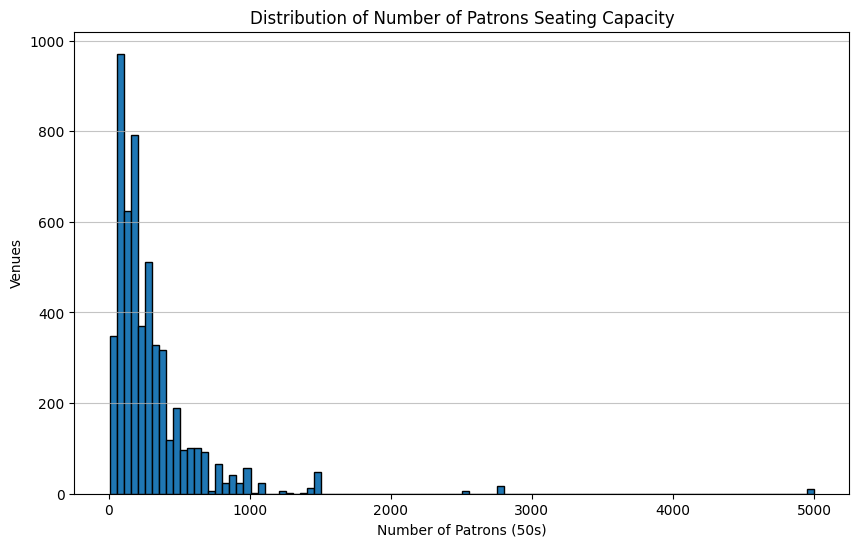

In [54]:
import matplotlib.pyplot as plt

# Create a histogram for 'Number of patrons'
plt.figure(figsize=(10, 6))
plt.hist(df['Number of patrons'].dropna(), bins=100, edgecolor='black')
plt.title('Distribution of Number of Patrons Seating Capacity')
plt.xlabel('Number of Patrons (50s)')
plt.ylabel('Venues')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [49]:
# Work out arrivals and departures per year from the first and last year for each property, and note the censored years.

df['Trading name'] = df['Trading name'].str.lower()

filtered_df = df.groupby('Trading name').agg(
    Open = ('Census year', min),
    Close = ('Census year', max)
)

print(filtered_df)
print(filtered_df[filtered_df['Open'] == 2002].count())
print(filtered_df[filtered_df['Open'] == 2024].count())

                           Open  Close
Trading name                          
24 moons                   2011   2012
44 bar                     2002   2003
adelphi hotel              2002   2006
aerial events              2015   2018
agostino                   2020   2021
...                         ...    ...
yarra falls                2022   2024
young & jackson            2002   2011
young & jacksons           2012   2024
zinc                       2022   2023
zinc at federation square  2005   2024

[823 rows x 2 columns]
Open     97
Close    97
dtype: int64
Open     47
Close    47
dtype: int64


/tmp/ipykernel_2777/3614003187.py:5: FutureWarning: The provided callable <built-in function min> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  filtered_df = df.groupby('Trading name').agg(
/tmp/ipykernel_2777/3614003187.py:5: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  filtered_df = df.groupby('Trading name').agg(


In [28]:
# Finding unique values of various columns given they are grouped together by property ID

def max_p_id(column_name):    #Takes a column name from sorted_by_id, finds the Property ID with the maximum value
                              #in that column, and returns the rows from the original df DataFrame for that Property ID.
    if column_name not in sorted_by_id.columns:
        print(f"Error: Column '{column_name}' not found in sorted_by_id.")
        return None

    max_property_id = sorted_by_id[column_name].idxmax()        # Get the Property ID with the maximum value in the specified column
    filtered_df = df[df['Property ID'] == max_property_id]      # Filter the original df DataFrame by this Property ID

    return filtered_df


sorted_by_id = df.groupby('Property ID').agg(                     #New data set that groups each row into the same Property ID
    Trade_Name_count = ('Trading name', 'nunique'),               #Using .agg each column is a count of unique values.
    Business_add_count =('Business address', 'nunique'),          #This will highlight how many different values share the same property id for each column
    Long_count = ('Longitude', 'nunique'),
    Lat_count = ('Latitude', 'nunique'),
    Loc_count = ('location', 'nunique')
)

print(sorted_by_id.describe())                                    #Summerise values

max_p_id('Trade_Name_count')                                      #Run function

       Trade_Name_count  Business_add_count  Long_count   Lat_count  \
count        389.000000          389.000000  389.000000  389.000000   
mean           2.195373            2.503856    2.619537    2.064267   
std            2.239035            2.075411    1.257648    1.014576   
min            1.000000            1.000000    1.000000    1.000000   
25%            1.000000            1.000000    2.000000    1.000000   
50%            2.000000            2.000000    2.000000    2.000000   
75%            3.000000            3.000000    3.000000    2.000000   
max           33.000000           23.000000    9.000000    9.000000   

        Loc_count  
count  389.000000  
mean     2.634961  
std      1.272392  
min      1.000000  
25%      2.000000  
50%      3.000000  
75%      3.000000  
max      9.000000  


,Census year,Block ID,Property ID,Base property ID,Building address,CLUE small area,Trading name,Business address,Number of patrons,Longitude,Latitude,location
208,2006,803,111175,110477,8 Whiteman Street SOUTHBANK 3006,Southbank,Cafe Greco,"Shop 18, Ground , 8 Whiteman Street SOUTHBANK ...",508,144.95867,-37.823123,"-37.82312301, 144.958669665"
209,2006,803,111175,110477,8 Whiteman Street SOUTHBANK 3006,Southbank,Fidel's Bar & Lounge,"Shop 61, Basement 0, 8-0 Whiteman Street SOUTH...",100,144.95867,-37.823123,"-37.82312301, 144.958669665"
267,2007,803,111175,110477,8 Whiteman Street SOUTHBANK 3006,Southbank,Number 8,"Shop 11, Ground , 8 Whiteman Street SOUTHBANK ...",200,144.95867,-37.823123,"-37.82312301, 144.958669665"
268,2007,803,111175,110477,8 Whiteman Street SOUTHBANK 3006,Southbank,Automatic Cafe,"Shop 30, Ground , 8 Whiteman Street SOUTHBANK ...",340,144.95867,-37.823123,"-37.82312301, 144.958669665"
269,2007,803,111175,110477,8 Whiteman Street SOUTHBANK 3006,Southbank,The Pub At Crown,"Shop 46, Ground 0, 8-0 Whiteman Street SOUTHBA...",300,144.95867,-37.823123,"-37.82312301, 144.958669665"
...,...,...,...,...,...,...,...,...,...,...,...,...
5188,2023,803,111175,110477,Crown Entertainment Complex 8 Whiteman Street ...,Southbank,Atrium Bar,"Shop 70, Ground 8 Whiteman Street SOUTHBANK VI...",100,144.95866,-37.823122,"-37.82312164, 144.958660189"
5189,2023,803,111175,110477,Crown Entertainment Complex 8 Whiteman Street ...,Southbank,Lumia Bar,"Shop 73, Ground 8 Whiteman Street SOUTHBANK VI...",140,144.95866,-37.823122,"-37.82312164, 144.958660189"
5292,2024,803,111175,110477,Crown Entertainment Complex 8 Whiteman Street ...,Southbank,The Pub at Crown,Part Casino 8 Whiteman Street SOUTHBANK VIC 3006,650,144.95866,-37.823122,"-37.82312164, 144.958660189"
5293,2024,803,111175,110477,Crown Entertainment Complex 8 Whiteman Street ...,Southbank,Velvet Bar,Part Casino 8 Whiteman Street SOUTHBANK VIC 3006,200,144.95866,-37.823122,"-37.82312164, 144.958660189"


In [ ]:
print(df[['Trading name', 'Number of patrons']].count(), '\n')

df_bar = df.groupby('Trading name')[['Census year', 'Number of patrons']]     #new data frame = Grouping the og data frame by commodity and then adding a revenue column by summing each price witihn a particular group

print(df_bar.count())